In [2]:
!pip install pandas

In [1]:
import pandas as pd
import torch
import torch.nn.functional as F
import torchvision.transforms as transforms
from torchvision import models
from PIL import Image
import os
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
!mc cp "s3/hlegarzic/stat_app/breast-level_annotations.csv" "/home/onyxia/breast-level_annotations.csv"

...ations.csv: 2.72 MiB / 2.72 MiB ┃▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓┃ 19.44 MiB/s 0s

In [6]:
# Chargement et filtrage des annotations
df = pd.read_csv("/home/onyxia/breast-level_annotations.csv")
df = df[df["view_position"] == "MLO"]
df = df[df["breast_birads"].isin(["BI-RADS 1", "BI-RADS 2", "BI-RADS 3", "BI-RADS 4", "BI-RADS 5"])]
df["label"] = (df["breast_birads"] == "BI-RADS 1").astype(int)  # 1=normal, 0=cancer

In [7]:
!mc mirror "s3/hlegarzic/stat_app/images_png" "/home/onyxia/images_png"
images_dir = "/home/onyxia/images_png"

...57212e.png: 7.70 GiB / 7.70 GiB ┃▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓┃ 340.32 MiB/s 23s

In [8]:
# Restructuration VinDr
import os
import shutil

destination_normal = "/home/onyxia/data/vindr/normal"
destination_cancer = "/home/onyxia/data/vindr/cancer_benign"
os.makedirs(destination_normal, exist_ok=True)
os.makedirs(destination_cancer, exist_ok=True)

for _, row in tqdm(df.iterrows(), total=len(df)):
    img_path = os.path.join(images_dir, row["study_id"], row["image_id"] + ".png")
    if not os.path.exists(img_path):
        continue
    if row["label"] == 1:
        shutil.copy2(img_path, destination_normal)
    else:
        shutil.copy2(img_path, destination_cancer)

# Vérification
for classe in ["normal", "cancer_benign"]:
    nb = len(os.listdir(f"/home/onyxia/data/vindr/{classe}"))
    print(f"  - {classe}: {nb} images")

# Sauvegarde sur S3
!mc cp -r /home/onyxia/data/vindr/ s3/hlegarzic/stat_app/vindr_restructure/

100%|██████████| 9999/9999 [00:13<00:00, 760.02it/s] 

  - normal: 6703 images
  - cancer_benign: 3296 images
]11;?\

...cdc4dc.png: 4.20 GiB / 4.20 GiB ┃▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓┃ 298.14 MiB/s 14s

In [7]:
# Chargement du modèle
!mc cp "s3/hlegarzic/stat_app/best_resnet18_model.pth" "/home/onyxia/best_resnet18_model.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet18()
model.fc = torch.nn.Linear(model.fc.in_features, 2)
model.load_state_dict(torch.load("/home/onyxia/best_resnet18_model.pth", map_location=device))
model.eval().to(device)

..._model.pth: 42.72 MiB / 42.72 MiB ┃▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓┃ 137.54 MiB/s 0s
== WARN: `minio.lab.sspcloud.fr` certificate will expire in 2026-02-26 12:48:48 +0000 UTC. Renew soon to avoid outage.



ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [8]:
# Transforms
transform = transforms.Compose([
    transforms.Resize((700, 700)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [11]:
# Inférence
!mc mirror "s3/hlegarzic/stat_app/images_png" "/home/onyxia/images_png"
images_dir = "/home/onyxia/images_png"

all_predictions = []
all_labels = []
all_probabilities = []

for _, row in tqdm(df.iterrows(), total=len(df)):
    img_path = os.path.join(images_dir, row["study_id"], row["image_id"] + ".png")
    
    if not os.path.exists(img_path):
        continue
    
    img = Image.open(img_path).convert("RGB")
    img_tensor = transform(img).unsqueeze(0).to(device)
    
    with torch.no_grad():
        outputs = model(img_tensor)
        probabilities = F.softmax(outputs, dim=1)
        _, pred = torch.max(outputs, 1)
        all_predictions.append(pred.item())
        all_labels.append(row["label"])
        all_probabilities.append(probabilities[0][0].item())

predictions_np = np.array(all_predictions)
labels_np = np.array(all_labels)
probabilities_np = np.array(all_probabilities)

accuracy = np.mean(predictions_np == labels_np)
print(f'Test_Accuracy : {accuracy*100:.4f}%')

...57212e.png: 7.70 GiB / 7.70 GiB ┃▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓┃ 275.20 MiB/s 28s
== WARN: `minio.lab.sspcloud.fr` certificate will expire in 2026-02-26 12:48:48 +0000 UTC. Renew soon to avoid outage.



100%|██████████| 9999/9999 [10:12<00:00, 16.34it/s]

Test_Accuracy : 67.1367%


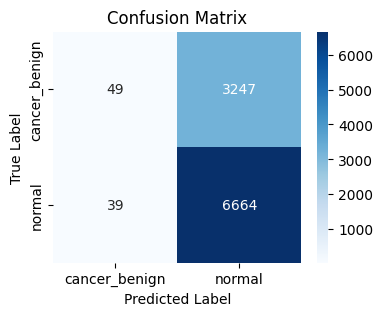

Rapport de classification : 
               precision    recall  f1-score   support

cancer_benign       0.56      0.01      0.03      3296
       normal       0.67      0.99      0.80      6703

     accuracy                           0.67      9999
    macro avg       0.61      0.50      0.42      9999
 weighted avg       0.63      0.67      0.55      9999



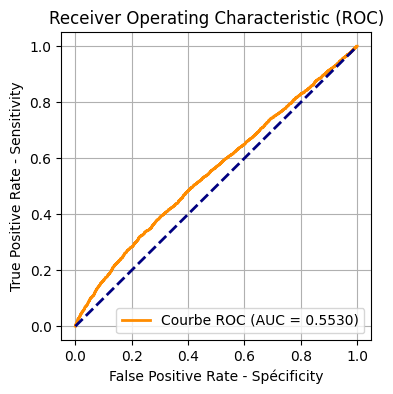

In [12]:
# Matrice de confusion
class_names = ['cancer_benign', 'normal']
cm = confusion_matrix(labels_np, predictions_np)

plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Rapport de classification
report = classification_report(labels_np, predictions_np, target_names=class_names)
print("Rapport de classification : ")
print(report)

# Courbe ROC et AUC
fpr, tpr, thresholds = roc_curve(labels_np, probabilities_np, pos_label=0)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(4, 4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Courbe ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate - Spécificity')
plt.ylabel('True Positive Rate - Sensitivity')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()